In [2]:
#-------Set up environment--------
options(warn = -1, verbose=FALSE)
library(dplyr)
library(Seurat)
library(httr)
library(readr)
library(harmony)
library(MAST)
library(unixtools)
library(ggplot2)
library(cowplot)
library(future)
library(repr)
library(ggmin)
library(pheatmap)
set_config(config(ssl_verifypeer = 0L))
ulimit::memory_limit(250000)
setwd("/data/lucy/MacroFibroAtlas/2026")
set.tempdir("/data/lucy/tmp/")

soft   hard 
250000    Inf

In [3]:
mfatlas <- readRDS("mfatlas.rds")

# Run differential abundance across disease states

## Synovium - disease vs homeostasis 

In [733]:
syno.fibro <- subset(harmony.fibro, subset = tissue == "Synovium")

Constructing kNN graph with k:40

Checking valid object

Running refined sampling with reduced_dim

Checking meta.data validity

Counting cells in neighbourhoods



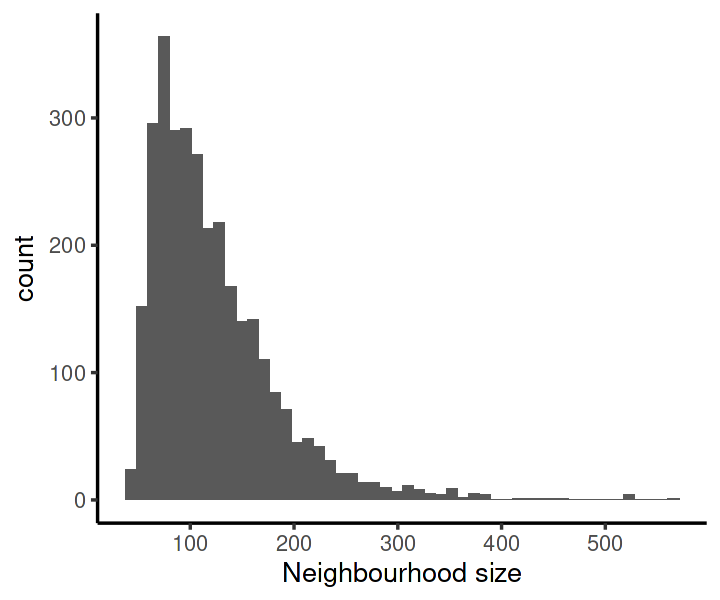

In [734]:
sce <- as.SingleCellExperiment(syno.fibro)
milo <- Milo(sce)
#Define representative neighbourhoods
milo <- buildGraph(milo, k = 40, d = 50, reduced.dim = "HARMONY")
milo <- makeNhoods(milo, prop = 0.2, k = 40, d=50, refined = TRUE, reduced_dims = "HARMONY")
#Counting cells in neighbourhoods
milo <- countCells(milo, meta.data = data.frame(colData(milo)), samples="sample")
#Once we have defined neighbourhoods, it’s good to take a look at how big the neighbourhoods are
#(i.e. how many cells form each neighbourhood). 
#This affects the power of DA testing. 
#We can check this out using the plotNhoodSizeHist function. 
#Empirically, we found it’s best to have a distribution peaking between 50 and 100. 
#Otherwise you might consider rerunning makeNhoods increasing k and/or prop (here the distribution looks ludicrous because it’s a small dataset).
plotNhoodSizeHist(milo)

In [47]:
#Differential abundance testing
design <- data.frame(colData(milo))[,c("sample", "state")]
colnames(design) <- c("sample","state")
design <- distinct(design)
rownames(design) <- design$sample

In [48]:
contrast <- c("stateDisease - stateHomeostasis") # the syntax is <VariableName><ConditionLevel> - <VariableName><ControlLevel>

# we need to use the ~ 0 + Variable expression here so that we have all of the levels of our variable as separate columns in our model matrix
syno_state_da_results <- testNhoods(milo, design = ~ 0 + state, design.df = design, model.contrasts = contrast,
                         fdr.weighting="graph-overlap", norm.method="TMM")

Using TMM normalisation

Running with model contrasts

Performing spatial FDR correction with graph-overlap weighting



In [49]:
syno_state_da_results %>% arrange(- SpatialFDR) %>% head() 
milo <- buildNhoodGraph(milo)

,logFC,logCPM,F,PValue,FDR,Nhood,SpatialFDR
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
293,-0.0004212703,9.105706,3.479444e-10,0.9999851,0.9999851,293,0.9999851
809,0.0011488700,10.169928,5.464180e-06,0.9981349,0.9984950,809,0.9985759
1735,-0.0048842123,9.456518,7.076402e-06,0.9978775,0.9984950,1735,0.9984877
2361,0.0027945949,9.354267,3.773697e-05,0.9950986,0.9961763,2361,0.9966962
1043,0.0114104596,9.327532,6.256383e-05,0.9936890,0.9951245,1043,0.9956730
1348,-0.0076249626,9.852214,6.876274e-05,0.9933838,0.9951245,1348,0.9956730


Adding nhood effect sizes to neighbourhood graph attributes

Scale for fill is already present.
Adding another scale for fill, which will replace the existing scale.


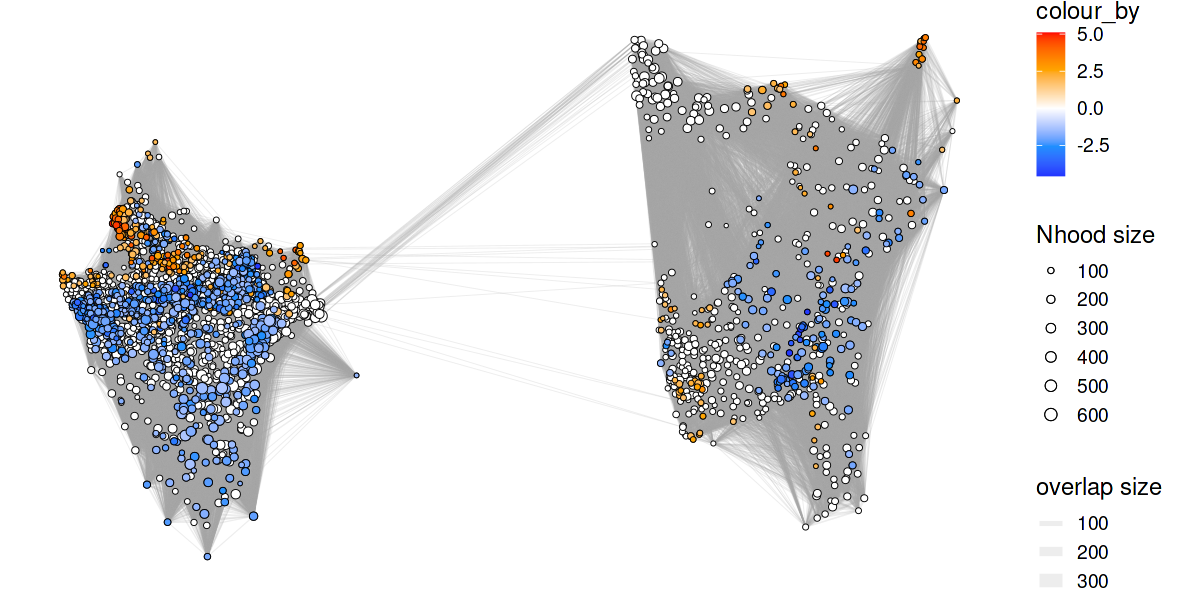

In [50]:
options(repr.plot.width=10, repr.plot.height=5)
plotNhoodGraphDA(milo, syno_state_da_results, alpha=0.1) +
  scale_fill_gradientn(
    colours = c("blue", "dodgerblue", "white", "orange", "red"),
    rescaler = ~ scales::rescale_mid(.x, mid = 0))

## Plot summary of disease state DA comparisons

In [600]:
heart_state_da_results$tissue <- "Heart"
lung_state_da_results$tissue <- "Lung"
skin_state_da_results$tissue <- "Skin"
syno_state_da_results$tissue <- "Synovium"


In [601]:
ncol(heart_state_da_results)

[1] 10

In [710]:
state_da_results <- rbind(heart_state_da_results,lung_state_da_results,skin_state_da_results,syno_state_da_results)

In [711]:
state_da_results$tissue_cluster <- paste0(state_da_results$tissue, "_", state_da_results$finalclusters)

In [702]:
no.nhood <- as.data.frame(table(state_da_results$tissue_cluster))
head(no.nhood)

,Var1,Freq
,<fct>,<int>
1,Heart_A2M+ Fibroblast,10
2,Heart_ACTA2+ Fibroblast,4
3,Heart_APOE+ Fibroblast,70
4,Heart_CDH19+ Fibroblast,5013
5,Heart_SPARC+ Fibroblast,5
6,Lung_A2M+ Fibroblast,167


In [706]:
sig_clusters <- no.nhood[which(no.nhood$Freq>5),"Var1"]

In [712]:
# Optional: Subset for significant neighbourhoods
da_results_sig <- state_da_results %>% filter(SpatialFDR < 0.1)
da_results_sig <- da_results_sig[da_results_sig$tissue_cluster%in%sig_clusters,]
# Calculate average logFC by cell type
cluster_logFC <- da_results_sig %>%
  group_by(tissue_cluster) %>%
  summarise(MeanLogFC = mean(logFC)) 
library(ComplexHeatmap)

In [715]:
cluster_logFC$tissue <- sub('_.*', '', cluster_logFC$tissue_cluster)
cluster_logFC$cluster <- sub('.*_', '', cluster_logFC$tissue_cluster)

In [731]:
cluster_logFC$cluster <- as.ordered(factor(cluster_logFC$cluster, rev(levels(harmony.fibro))))

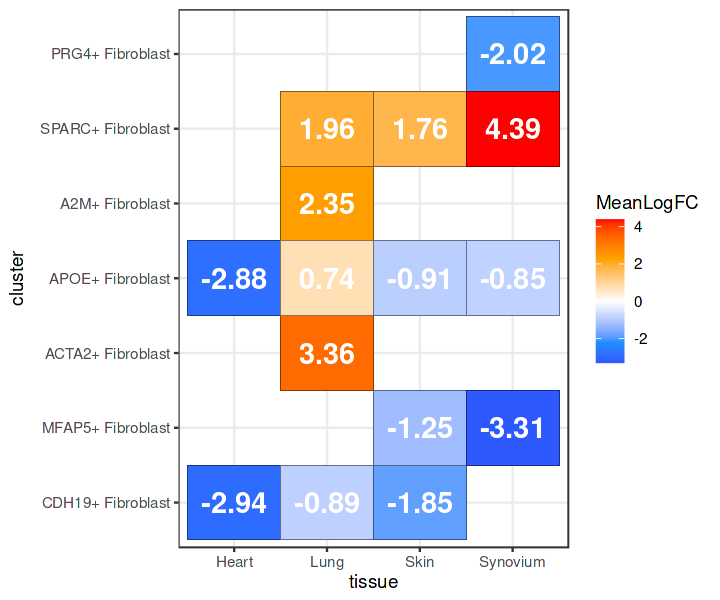

In [732]:
options(repr.plot.width=6, repr.plot.height=5)
ggplot(cluster_logFC, aes(tissue, cluster, fill= MeanLogFC)) + 
  geom_tile(color="black")+
  scale_fill_gradientn(
    colours = c("blue", "dodgerblue", "white", "orange", "red"),
    rescaler = ~ scales::rescale_mid(.x, mid = 0))  +  geom_text(aes(label = round(MeanLogFC,2)),size = 6, color = "white", fontface="bold") + theme_bw() 


# Run differential abundance analysis across conditions 

In [736]:
syno.fibro <- subset(harmony.fibro, subset = tissue == "Synovium")

Constructing kNN graph with k:40

Checking valid object

Running refined sampling with reduced_dim

Checking meta.data validity

Counting cells in neighbourhoods



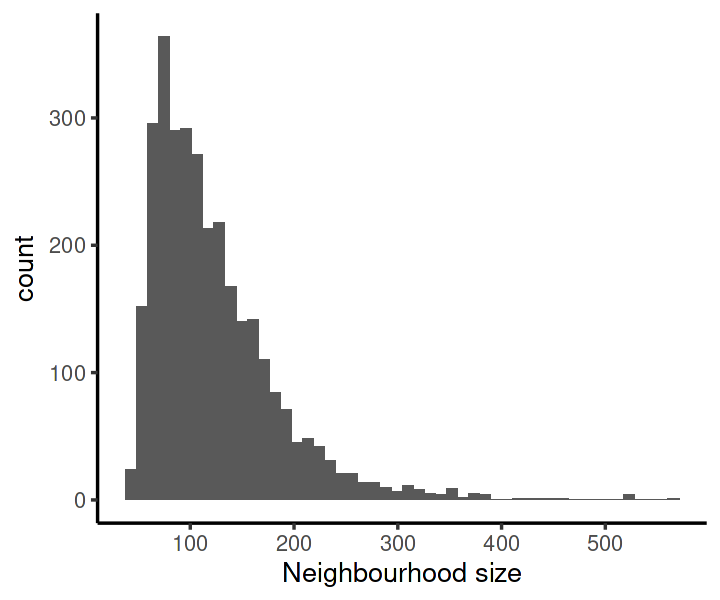

In [737]:
sce <- as.SingleCellExperiment(syno.fibro)
milo <- Milo(sce)
#Define representative neighbourhoods
milo <- buildGraph(milo, k = 40, d = 50, reduced.dim = "HARMONY")
milo <- makeNhoods(milo, prop = 0.2, k = 40, d=50, refined = TRUE, reduced_dims = "HARMONY")
#Counting cells in neighbourhoods
milo <- countCells(milo, meta.data = data.frame(colData(milo)), samples="sample")
#Once we have defined neighbourhoods, it’s good to take a look at how big the neighbourhoods are
#(i.e. how many cells form each neighbourhood). 
#This affects the power of DA testing. 
#We can check this out using the plotNhoodSizeHist function. 
#Empirically, we found it’s best to have a distribution peaking between 50 and 100. 
#Otherwise you might consider rerunning makeNhoods increasing k and/or prop (here the distribution looks ludicrous because it’s a small dataset).
plotNhoodSizeHist(milo)

In [748]:
#Differential abundance testing
design <- data.frame(colData(milo))[,c("sample", "disease")]
colnames(design) <- c("sample","disease")
design <- distinct(design)
rownames(design) <- design$sample
design$disease <- make.names(design$disease)


In [749]:
design

,sample,disease
,<chr>,<chr>
Stephenson2018_RA1,Stephenson2018_RA1,Active.RA
Stephenson2018_RA2,Stephenson2018_RA2,Active.RA
Stephenson2018_RA3,Stephenson2018_RA3,Active.RA
Stephenson2018_RA4,Stephenson2018_RA4,Active.RA
Stephenson2018_RA5,Stephenson2018_RA5,Active.RA
Zhang2019_S006,Zhang2019_S006,OA
Zhang2019_S008,Zhang2019_S008,OA
Zhang2019_S010,Zhang2019_S010,Active.RA
Zhang2019_S011,Zhang2019_S011,OA


In [750]:
contrast.all <- c("diseaseActive.RA - diseaseRA.in.Remission","diseaseOA - diseaseRA.in.Remission") # the syntax is <VariableName><ConditionLevel> - <VariableName><ControlLevel>

# this is the edgeR code called by `testNhoods`
model <- model.matrix(~ 0 + disease, data=design)
mod.constrast <- makeContrasts(contrasts=contrast.all, levels=model)

mod.constrast

,diseaseActive.RA - diseaseRA.in.Remission,diseaseOA - diseaseRA.in.Remission
diseaseActive.RA,1,0
diseaseOA,0,1
diseaseRA.in.Remission,-1,-1


In [757]:
# compare weeks 4 and 16, with week 4 as the reference.
syno_RAdisease_da_results <- testNhoods(milo, design=~0+ disease, design.df=design, fdr.weighting="graph-overlap", model.contrasts = c("diseaseActive.RA - diseaseRA.in.Remission"))


Using TMM normalisation

Running with model contrasts

Performing spatial FDR correction with graph-overlap weighting



In [758]:
syno_RAdisease_da_results %>% arrange(- SpatialFDR) %>% head() 
milo <- buildNhoodGraph(milo)

,logFC,logCPM,F,PValue,FDR,Nhood,SpatialFDR
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
251,0.001785797,10.48248,9.369018e-07,0.9992277,0.9992277,251,0.9992277
2447,-0.001928404,10.49752,9.507516e-07,0.9992220,0.9992277,2447,0.9992277
1448,-0.005184967,10.43504,6.520015e-06,0.9979627,0.9985975,1448,0.9983751
214,-0.011807896,10.10874,9.696175e-06,0.9975155,0.9985975,214,0.9982691
400,0.001867850,10.15340,9.331628e-06,0.9975627,0.9985975,400,0.9982691
896,-0.005943716,10.66880,2.092356e-05,0.9963503,0.9985722,896,0.9982691


Adding nhood effect sizes to neighbourhood graph attributes

Scale for fill is already present.
Adding another scale for fill, which will replace the existing scale.


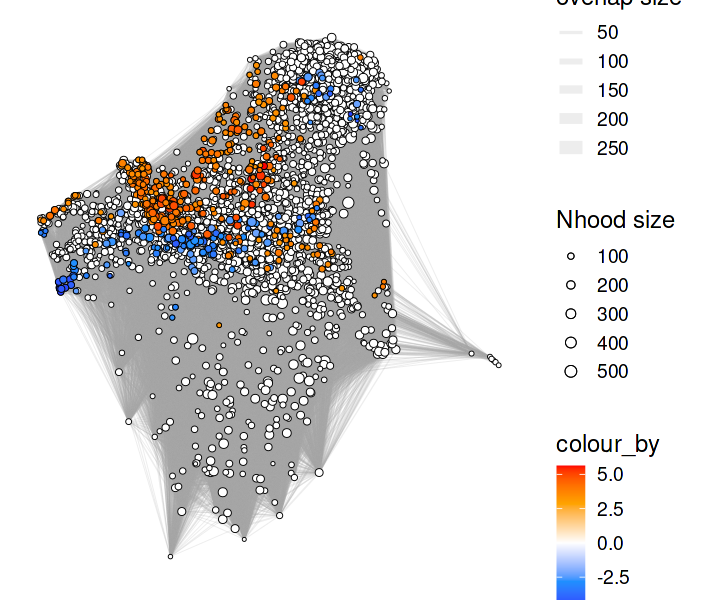

In [759]:
options(repr.plot.width=6, repr.plot.height=5)
plotNhoodGraphDA(milo, syno_RAdisease_da_results, alpha=0.1) +
  scale_fill_gradientn(
    colours = c("blue", "dodgerblue", "white", "orange", "red"),
    rescaler = ~ scales::rescale_mid(.x, mid = 0))

In [760]:
syno_RAdisease_da_results <- annotateNhoods(milo, syno_RAdisease_da_results, coldata_col = "finalclusters")
head(da_results)

logFC,logCPM,F,PValue,FDR,Nhood,SpatialFDR,finalclusters,finalclusters_fraction,group_median
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<ord>,<dbl>,<dbl>
2.0782518,11.42371,1.511603e+01,0.0001346758,0.0008768035,1,0.0006165537,CDH19+ Fibroblast,0.8672566,-0.3311743
1.3459243,11.29926,8.699330e+00,0.0065894915,0.0316124647,2,0.0263480901,CDH19+ Fibroblast,0.9740260,-0.3311743
-0.8585617,11.34609,8.172374e-08,0.9997721992,1.0000000000,3,1.0000000000,CDH19+ Fibroblast,1.0000000,-0.3311743
-1.2186092,11.68364,2.993348e-07,0.9996479898,1.0000000000,4,1.0000000000,CDH19+ Fibroblast,1.0000000,-0.3311743
1.3476641,11.70575,7.520956e+00,0.0066120266,0.0317009944,5,0.0264359749,CDH19+ Fibroblast,0.9627907,-0.3311743
-0.8940673,11.36959,9.742100e-08,0.9998039000,1.0000000000,6,1.0000000000,CDH19+ Fibroblast,1.0000000,-0.3311743


In [761]:
syno_RAdisease_da_results$finalclusters <- as.ordered(factor(syno_RAdisease_da_results$finalclusters, levels=rev(c(c("PRG4+ Fibroblast","VCAM1+ Fibroblast","POSTN+ Fibroblast",
                                "A2M+ Fibroblast","APOE+ Fibroblast","ACTA2+ Fibroblast","MFAP5+ Fibroblast","CDH19+ Fibroblast")))))

Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


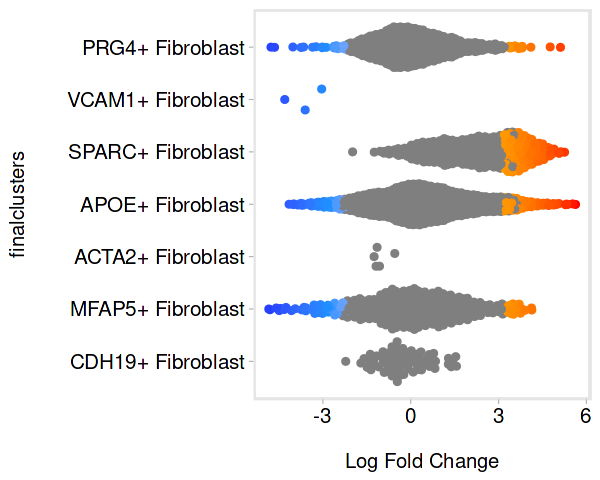

In [764]:
options(repr.plot.width=5, repr.plot.height=4)
plotDAbeeswarm(syno_RAdisease_da_results, group.by = "finalclusters") + theme_powerpoint() +
  scale_color_gradientn(
    colours = c("blue", "dodgerblue", "white", "orange", "red"),
    rescaler = ~ scales::rescale_mid(.x, mid = 0)) 


In [765]:
# compare weeks 4 and 16, with week 4 as the reference.
syno_OAdisease_da_results <- testNhoods(milo, design=~0+ disease, design.df=design, fdr.weighting="graph-overlap", model.contrasts = c("diseaseOA - diseaseRA.in.Remission"))


Using TMM normalisation

Running with model contrasts

Performing spatial FDR correction with graph-overlap weighting



In [766]:
syno_OAdisease_da_results %>% arrange(- SpatialFDR) %>% head() 
milo <- buildNhoodGraph(milo)

,logFC,logCPM,F,PValue,FDR,Nhood,SpatialFDR
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
15,0.00000000,10.313373,0.0000000000,1.0000000,1,15,1
18,0.05292207,10.128907,0.0008151821,0.9946729,1,18,1
33,0.00000000,10.417326,0.0000000000,1.0000000,1,33,1
41,0.00000000,10.554869,0.0000000000,1.0000000,1,41,1
57,0.00000000,10.029914,0.0000000000,1.0000000,1,57,1
62,0.00000000,9.906163,0.0000000000,1.0000000,1,62,1


Adding nhood effect sizes to neighbourhood graph attributes

Scale for fill is already present.
Adding another scale for fill, which will replace the existing scale.


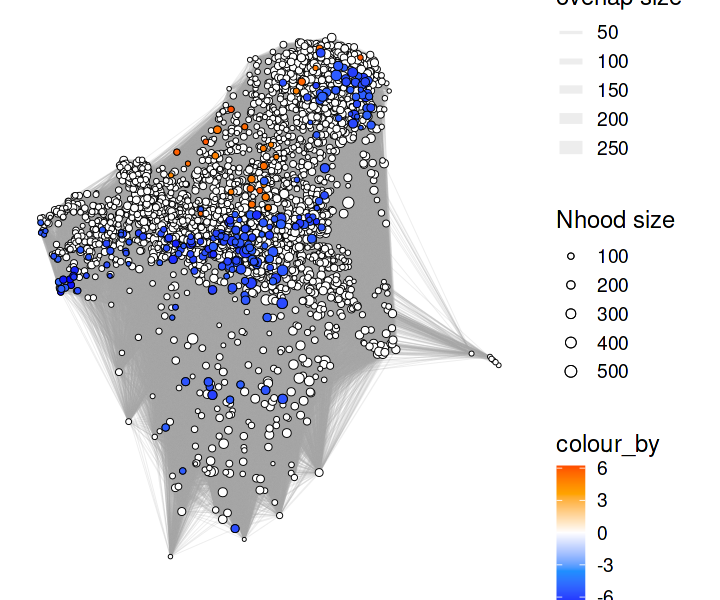

In [767]:
options(repr.plot.width=6, repr.plot.height=5)
plotNhoodGraphDA(milo, syno_OAdisease_da_results, alpha=0.1) +
  scale_fill_gradientn(
    colours = c("blue", "dodgerblue", "white", "orange", "red"),
    rescaler = ~ scales::rescale_mid(.x, mid = 0))

In [768]:
syno_OAdisease_da_results <- annotateNhoods(milo, syno_OAdisease_da_results, coldata_col = "finalclusters")
head(da_results)

logFC,logCPM,F,PValue,FDR,Nhood,SpatialFDR,finalclusters,finalclusters_fraction,group_median
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<ord>,<dbl>,<dbl>
2.0782518,11.42371,1.511603e+01,0.0001346758,0.0008768035,1,0.0006165537,CDH19+ Fibroblast,0.8672566,-0.3311743
1.3459243,11.29926,8.699330e+00,0.0065894915,0.0316124647,2,0.0263480901,CDH19+ Fibroblast,0.9740260,-0.3311743
-0.8585617,11.34609,8.172374e-08,0.9997721992,1.0000000000,3,1.0000000000,CDH19+ Fibroblast,1.0000000,-0.3311743
-1.2186092,11.68364,2.993348e-07,0.9996479898,1.0000000000,4,1.0000000000,CDH19+ Fibroblast,1.0000000,-0.3311743
1.3476641,11.70575,7.520956e+00,0.0066120266,0.0317009944,5,0.0264359749,CDH19+ Fibroblast,0.9627907,-0.3311743
-0.8940673,11.36959,9.742100e-08,0.9998039000,1.0000000000,6,1.0000000000,CDH19+ Fibroblast,1.0000000,-0.3311743


In [770]:
syno_OAdisease_da_results$finalclusters <- as.ordered(factor(syno_OAdisease_da_results$finalclusters, levels=rev(c(c("PRG4+ Fibroblast","VCAM1+ Fibroblast","POSTN+ Fibroblast",
                                "A2M+ Fibroblast","APOE+ Fibroblast","ACTA2+ Fibroblast","MFAP5+ Fibroblast","CDH19+ Fibroblast")))))

Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


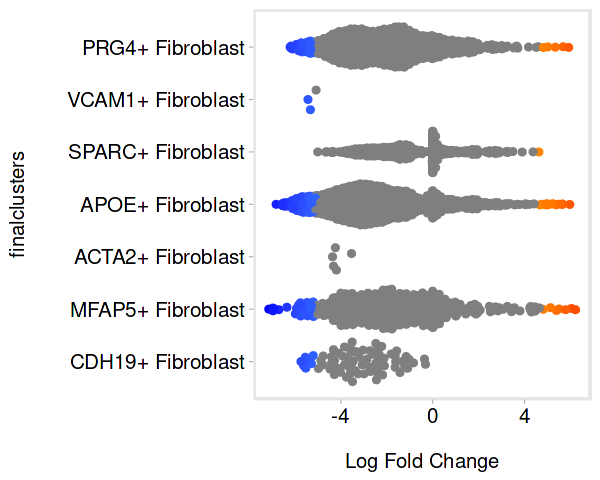

In [771]:
options(repr.plot.width=5, repr.plot.height=4)
plotDAbeeswarm(syno_OAdisease_da_results, group.by = "finalclusters") + theme_powerpoint() +
  scale_color_gradientn(
    colours = c("blue", "dodgerblue", "white", "orange", "red"),
    rescaler = ~ scales::rescale_mid(.x, mid = 0)) 


# Run differential abundance across disease states

## Heart - disease vs homeostasis 

In [58]:
heart.atlas <- subset(mfatlas, subset = tissue == "Heart")

Constructing kNN graph with k:40

Checking valid object

Running refined sampling with reduced_dim

Checking meta.data validity

Counting cells in neighbourhoods



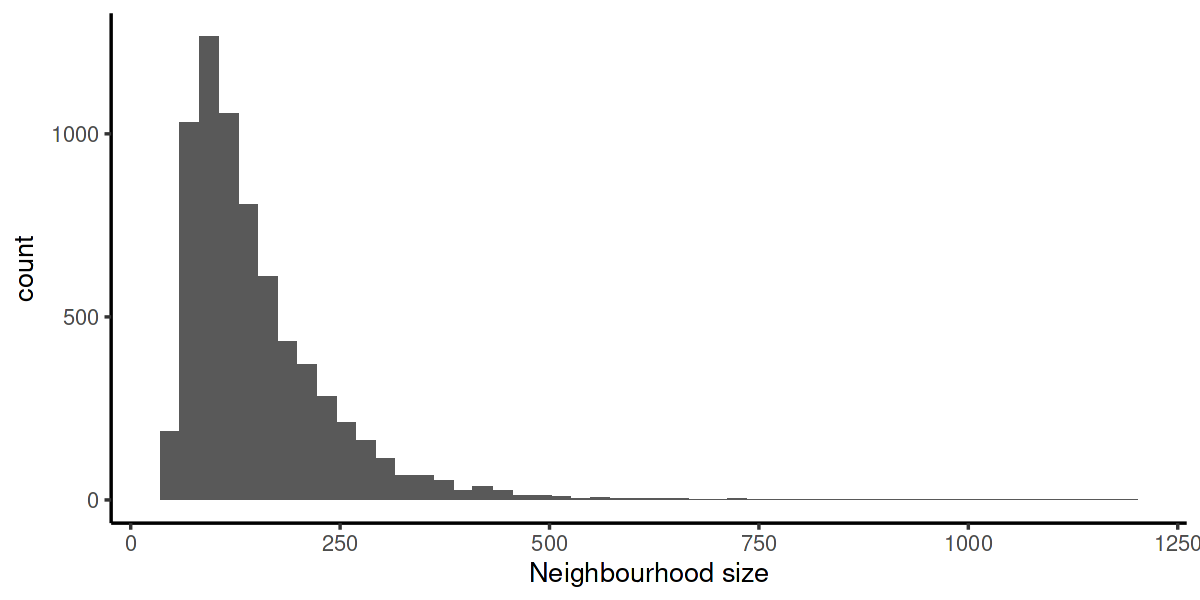

In [59]:
sce <- as.SingleCellExperiment(heart.atlas)
milo <- Milo(sce)
#Define representative neighbourhoods
milo <- buildGraph(milo, k = 40, d = 50, reduced.dim = "HARMONY")
milo <- makeNhoods(milo, prop = 0.2, k = 40, d=50, refined = TRUE, reduced_dims = "HARMONY")
#Counting cells in neighbourhoods
milo <- countCells(milo, meta.data = data.frame(colData(milo)), samples="sample")
#Once we have defined neighbourhoods, it’s good to take a look at how big the neighbourhoods are
#(i.e. how many cells form each neighbourhood). 
#This affects the power of DA testing. 
#We can check this out using the plotNhoodSizeHist function. 
#Empirically, we found it’s best to have a distribution peaking between 50 and 100. 
#Otherwise you might consider rerunning makeNhoods increasing k and/or prop (here the distribution looks ludicrous because it’s a small dataset).
plotNhoodSizeHist(milo)

In [60]:
#Differential abundance testing
design <- data.frame(colData(milo))[,c("sample", "state")]
colnames(design) <- c("sample","state")
design <- distinct(design)
rownames(design) <- design$sample

In [61]:
contrast <- c("stateDisease - stateHomeostasis") # the syntax is <VariableName><ConditionLevel> - <VariableName><ControlLevel>

# we need to use the ~ 0 + Variable expression here so that we have all of the levels of our variable as separate columns in our model matrix
heart_state_da_results <- testNhoods(milo, design = ~ 0 + state, design.df = design, model.contrasts = contrast,
                         fdr.weighting="graph-overlap", norm.method="TMM")

Using TMM normalisation

Running with model contrasts

Performing spatial FDR correction with graph-overlap weighting



In [62]:
heart_state_da_results %>% arrange(- SpatialFDR) %>% head() 
milo <- buildNhoodGraph(milo)

,logFC,logCPM,F,PValue,FDR,Nhood,SpatialFDR
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
943,0.01044833,9.953557,2.624776e-06,0.9987086,0.9987086,943,0.9987086
6145,0.01236176,9.616122,5.745541e-05,0.9939582,0.9941027,6145,0.9940166
2277,0.11902308,9.993282,1.528468e-02,0.9902898,0.9905777,2277,0.9905847
6041,0.02795462,9.944263,2.963562e-04,0.9862789,0.9867091,6041,0.9866730
3835,0.33946883,9.831035,1.324995e-01,0.9856259,0.9861992,3835,0.9860810
3065,0.26645395,9.587161,7.123039e-02,0.9831525,0.9838674,3065,0.9837392


Adding nhood effect sizes to neighbourhood graph attributes

Scale for fill is already present.
Adding another scale for fill, which will replace the existing scale.


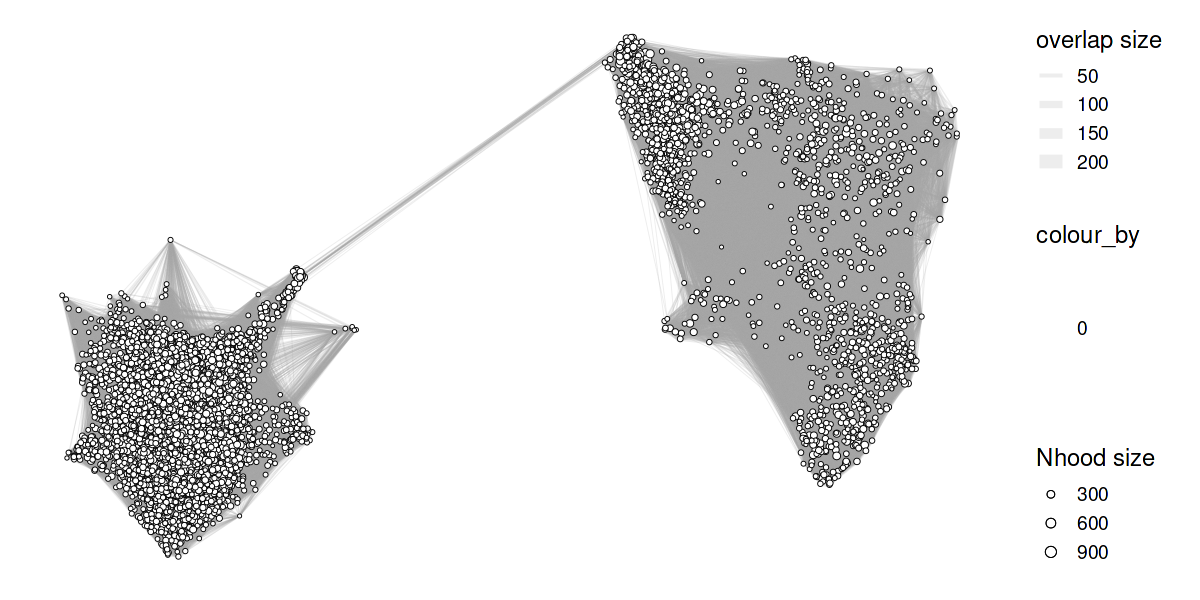

In [63]:
options(repr.plot.width=10, repr.plot.height=5)
plotNhoodGraphDA(milo, heart_state_da_results, alpha=0.1) +
  scale_fill_gradientn(
    colours = c("blue", "dodgerblue", "white", "orange", "red"),
    rescaler = ~ scales::rescale_mid(.x, mid = 0))

## Lung - disease vs homeostasis 

In [26]:
lung.atlas <- subset(mfatlas, subset = tissue == "Lung")

Constructing kNN graph with k:40

Checking valid object

Running refined sampling with reduced_dim

Checking meta.data validity

Counting cells in neighbourhoods



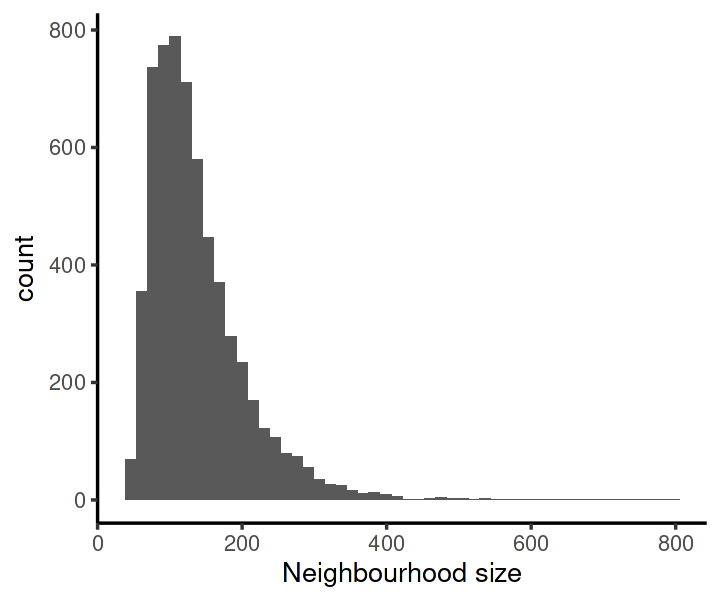

In [27]:
sce <- as.SingleCellExperiment(lung.atlas)
milo <- Milo(sce)
#Define representative neighbourhoods
milo <- buildGraph(milo, k = 40, d = 50, reduced.dim = "HARMONY")
milo <- makeNhoods(milo, prop = 0.2, k = 40, d=50, refined = TRUE, reduced_dims = "HARMONY")
#Counting cells in neighbourhoods
milo <- countCells(milo, meta.data = data.frame(colData(milo)), samples="sample")
#Once we have defined neighbourhoods, it’s good to take a look at how big the neighbourhoods are
#(i.e. how many cells form each neighbourhood). 
#This affects the power of DA testing. 
#We can check this out using the plotNhoodSizeHist function. 
#Empirically, we found it’s best to have a distribution peaking between 50 and 100. 
#Otherwise you might consider rerunning makeNhoods increasing k and/or prop (here the distribution looks ludicrous because it’s a small dataset).
plotNhoodSizeHist(milo)

In [28]:
#Differential abundance testing
design <- data.frame(colData(milo))[,c("sample", "state")]
colnames(design) <- c("sample","state")
design <- distinct(design)
rownames(design) <- design$sample

In [29]:
contrast <- c("stateDisease - stateHomeostasis") # the syntax is <VariableName><ConditionLevel> - <VariableName><ControlLevel>

# we need to use the ~ 0 + Variable expression here so that we have all of the levels of our variable as separate columns in our model matrix
lung_state_da_results <- testNhoods(milo, design = ~ 0 + state, design.df = design, model.contrasts = contrast,
                         fdr.weighting="graph-overlap", norm.method="TMM")

Using TMM normalisation

Running with model contrasts

Performing spatial FDR correction with graph-overlap weighting



In [30]:
lung_state_da_results %>% arrange(- SpatialFDR) %>% head() 
milo <- buildNhoodGraph(milo)

,logFC,logCPM,F,PValue,FDR,Nhood,SpatialFDR
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1566,-4.462336e-05,8.088819,6.671656e-09,0.9999350,0.9999350,1566,0.9999350
3210,4.471707e-04,8.121200,1.077864e-06,0.9991742,0.9995016,3210,0.9994135
5341,-5.831055e-03,7.621266,6.777203e-07,0.9993452,0.9995089,5341,0.9994135
110,2.988730e-04,8.315668,2.366975e-06,0.9987762,0.9992672,110,0.9991751
1831,1.286349e-03,8.308315,2.760916e-06,0.9986783,0.9992672,1831,0.9991409
5463,2.135856e-04,7.979926,3.875890e-06,0.9984340,0.9992523,5463,0.9989612


Adding nhood effect sizes to neighbourhood graph attributes

Scale for fill is already present.
Adding another scale for fill, which will replace the existing scale.


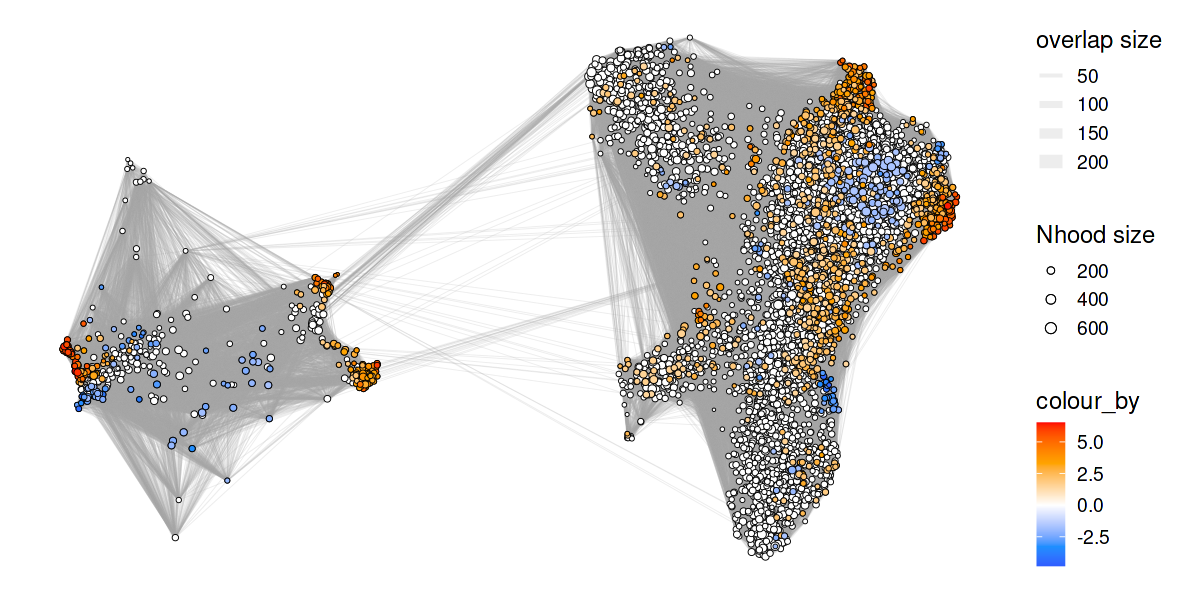

In [36]:
options(repr.plot.width=10, repr.plot.height=5)
plotNhoodGraphDA(milo, lung_state_da_results, alpha=0.1) +
  scale_fill_gradientn(
    colours = c("blue", "dodgerblue", "white", "orange", "red"),
    rescaler = ~ scales::rescale_mid(.x, mid = 0))

In [32]:
lung_state_da_results <- annotateNhoods(milo, lung_state_da_results, coldata_col = "finalclusters")
head(lung_state_da_results)

,logFC,logCPM,F,PValue,FDR,Nhood,SpatialFDR,finalclusters,finalclusters_fraction
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>
1,0.7454709,8.598961,1.4682530,0.22915188,0.4640801,1,0.40979906,LYVE1+ Macrophage,0.9832636
2,-0.8524877,8.179312,1.9273853,0.16885916,0.3926329,2,0.33643261,TREM2+ Macrophage,1.0000000
3,0.4625902,8.554921,0.4908349,0.48556693,0.6956527,3,0.65888674,TREM2+ Macrophage,0.9962406
4,1.4257686,8.683767,4.9786504,0.02843169,0.1340948,4,0.09552204,LYVE1+ Macrophage,0.9692982
5,1.1471403,7.758307,2.5185347,0.11641953,0.3143156,5,0.25968259,LYVE1+ Macrophage,1.0000000
6,-0.9819076,8.789929,2.1373984,0.14762259,0.3635576,6,0.30725889,TREM2+ Macrophage,0.9910180


In [37]:
lung_state_da_results$finalclusters <- as.ordered(factor(lung_state_da_results$finalclusters, levels=rev(c("LYVE1+ Macrophage","FOLR2+ Macrophage","TREM2+ Macrophage","ISG15+ Macrophage","SPP1+ Macrophage",
                                                          "IL1B+ Macrophage",
                                                         "CD14+S100A12+ Tissue Monocytes","CD16+ISG15+ Tissue Monocytes","CCR7+ DC","CD1c+ DC",
                                                         "Langerhans Cells (CD207+ DC)","PRG4+ Fibroblast","VCAM1+ Fibroblast","POSTN+ Fibroblast",
                                "A2M+ Fibroblast","APOE+ Fibroblast","ACTA2+ Fibroblast","MFAP5+ Fibroblast","CDH19+ Fibroblast"))))

## Skin - disease vs homeostasis 

In [41]:
skin.atlas <- subset(mfatlas, subset = tissue == "Skin")

Constructing kNN graph with k:40

Checking valid object

Running refined sampling with reduced_dim

Checking meta.data validity

Counting cells in neighbourhoods



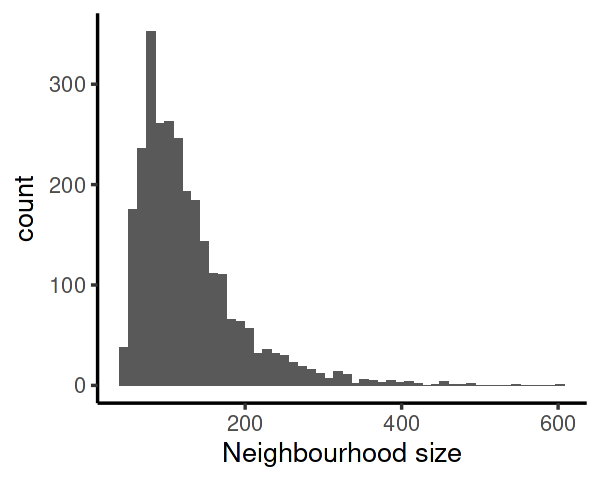

In [42]:
sce <- as.SingleCellExperiment(skin.atlas)
milo <- Milo(sce)
#Define representative neighbourhoods
milo <- buildGraph(milo, k = 40, d = 50, reduced.dim = "HARMONY")
milo <- makeNhoods(milo, prop = 0.2, k = 40, d=50, refined = TRUE, reduced_dims = "HARMONY")
#Counting cells in neighbourhoods
milo <- countCells(milo, meta.data = data.frame(colData(milo)), samples="sample")
#Once we have defined neighbourhoods, it’s good to take a look at how big the neighbourhoods are
#(i.e. how many cells form each neighbourhood). 
#This affects the power of DA testing. 
#We can check this out using the plotNhoodSizeHist function. 
#Empirically, we found it’s best to have a distribution peaking between 50 and 100. 
#Otherwise you might consider rerunning makeNhoods increasing k and/or prop (here the distribution looks ludicrous because it’s a small dataset).
plotNhoodSizeHist(milo)

In [43]:
#Differential abundance testing
design <- data.frame(colData(milo))[,c("sample", "state")]
colnames(design) <- c("sample","state")
design <- distinct(design)
rownames(design) <- design$sample

In [44]:
contrast <- c("stateDisease - stateHomeostasis") # the syntax is <VariableName><ConditionLevel> - <VariableName><ControlLevel>

# we need to use the ~ 0 + Variable expression here so that we have all of the levels of our variable as separate columns in our model matrix
skin_state_da_results <- testNhoods(milo, design = ~ 0 + state, design.df = design, model.contrasts = contrast,
                         fdr.weighting="graph-overlap", norm.method="TMM")

Using TMM normalisation

Running with model contrasts

Performing spatial FDR correction with graph-overlap weighting



In [45]:
skin_state_da_results %>% arrange(- SpatialFDR) %>% head() 
milo <- buildNhoodGraph(milo)

,logFC,logCPM,F,PValue,FDR,Nhood,SpatialFDR
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
293,-0.0004212703,9.105706,3.479444e-10,0.9999851,0.9999851,293,0.9999851
809,0.0011488700,10.169928,5.464180e-06,0.9981349,0.9984950,809,0.9985759
1735,-0.0048842123,9.456518,7.076402e-06,0.9978775,0.9984950,1735,0.9984877
2361,0.0027945949,9.354267,3.773697e-05,0.9950986,0.9961763,2361,0.9966962
1043,0.0114104596,9.327532,6.256383e-05,0.9936890,0.9951245,1043,0.9956730
1348,-0.0076249626,9.852214,6.876274e-05,0.9933838,0.9951245,1348,0.9956730


Adding nhood effect sizes to neighbourhood graph attributes

Scale for fill is already present.
Adding another scale for fill, which will replace the existing scale.


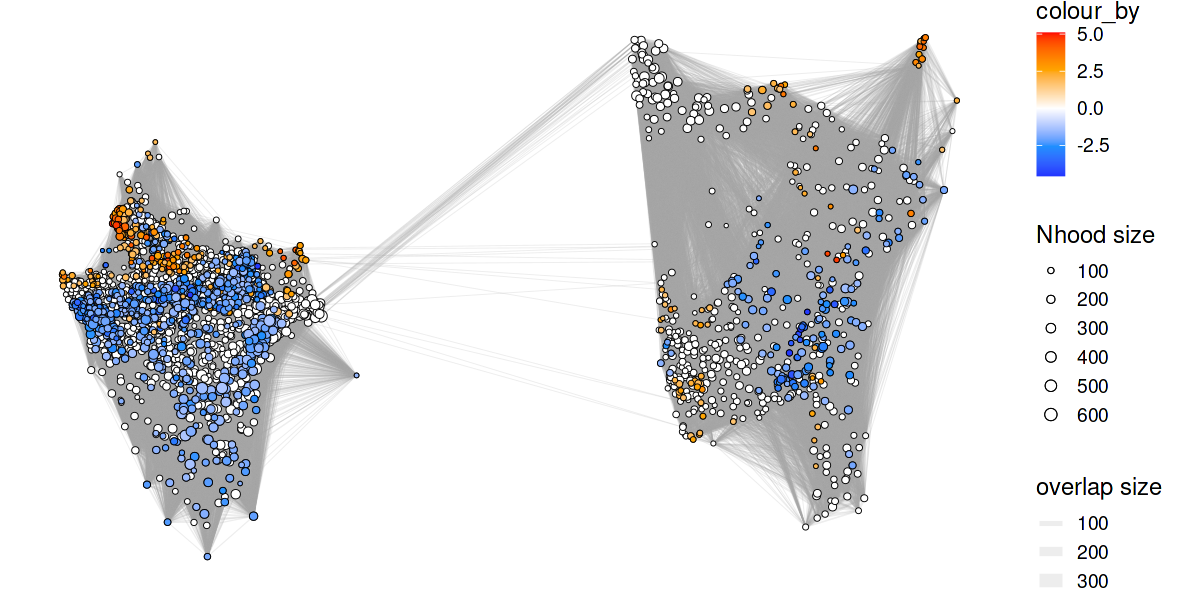

In [46]:
options(repr.plot.width=10, repr.plot.height=5)
plotNhoodGraphDA(milo, skin_state_da_results, alpha=0.1) +
  scale_fill_gradientn(
    colours = c("blue", "dodgerblue", "white", "orange", "red"),
    rescaler = ~ scales::rescale_mid(.x, mid = 0))

In [ ]:
skin_state_da_results <- annotateNhoods(milo, skin_state_da_results, coldata_col = "finalclusters")
head(da_results)

In [ ]:
skin_state_da_results$finalclusters <- as.ordered(factor(skin_state_da_results$finalclusters, levels=rev(c("LYVE1+ Macrophage","FOLR2+ Macrophage","TREM2+ Macrophage","ISG15+ Macrophage","SPP1+ Macrophage",
                                                          "IL1B+ Macrophage",
                                                         "CD14+S100A12+ Tissue Monocytes","CD16+ISG15+ Tissue Monocytes","CCR7+ DC","CD1c+ DC",
                                                         "Langerhans Cells (CD207+ DC)"))))

In [ ]:
options(repr.plot.width=5, repr.plot.height=4)
plotDAbeeswarm(skin_state_da_results, group.by = "finalclusters") + theme_powerpoint() +
  scale_color_gradientn(
    colours = c("blue", "dodgerblue", "white", "orange", "red"),
    rescaler = ~ scales::rescale_mid(.x, mid = 0)) 

## Synovium - disease vs homeostasis 

In [51]:
syno.atlas <- subset(mfatlas, subset = tissue == "Synovium")

Constructing kNN graph with k:40

Checking valid object

Running refined sampling with reduced_dim

Checking meta.data validity

Counting cells in neighbourhoods



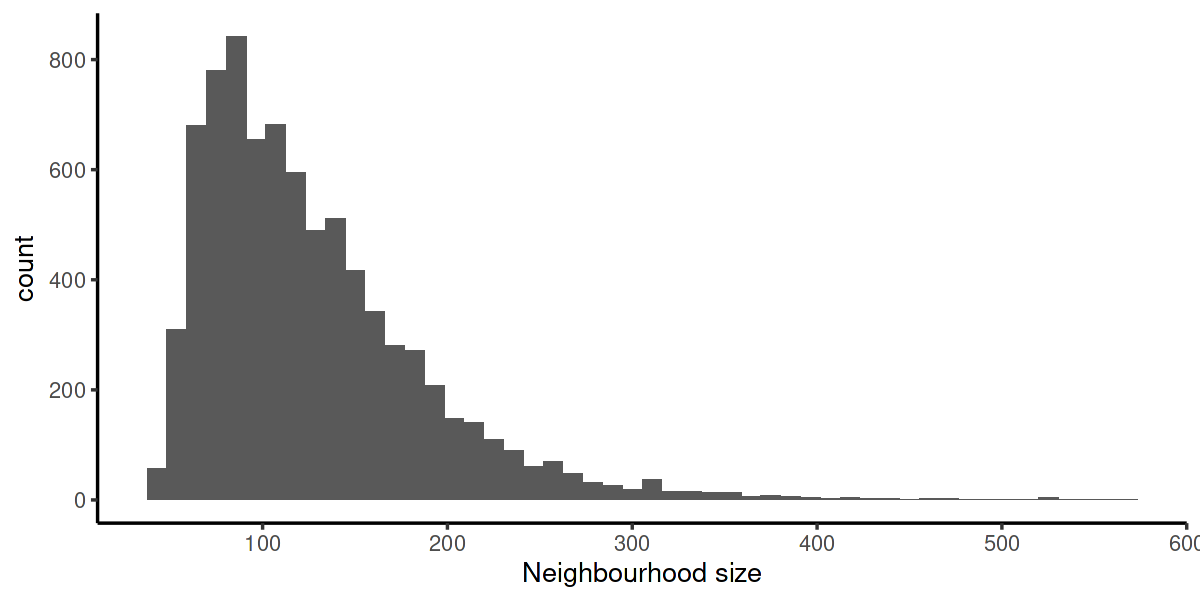

In [52]:
sce <- as.SingleCellExperiment(syno.atlas)
milo <- Milo(sce)
#Define representative neighbourhoods
milo <- buildGraph(milo, k = 40, d = 50, reduced.dim = "HARMONY")
milo <- makeNhoods(milo, prop = 0.2, k = 40, d=50, refined = TRUE, reduced_dims = "HARMONY")
#Counting cells in neighbourhoods
milo <- countCells(milo, meta.data = data.frame(colData(milo)), samples="sample")
#Once we have defined neighbourhoods, it’s good to take a look at how big the neighbourhoods are
#(i.e. how many cells form each neighbourhood). 
#This affects the power of DA testing. 
#We can check this out using the plotNhoodSizeHist function. 
#Empirically, we found it’s best to have a distribution peaking between 50 and 100. 
#Otherwise you might consider rerunning makeNhoods increasing k and/or prop (here the distribution looks ludicrous because it’s a small dataset).
plotNhoodSizeHist(milo)

In [53]:
#Differential abundance testing
design <- data.frame(colData(milo))[,c("sample", "state")]
colnames(design) <- c("sample","state")
design <- distinct(design)
rownames(design) <- design$sample

In [54]:
contrast <- c("stateDisease - stateHomeostasis") # the syntax is <VariableName><ConditionLevel> - <VariableName><ControlLevel>

# we need to use the ~ 0 + Variable expression here so that we have all of the levels of our variable as separate columns in our model matrix
syno_state_da_results <- testNhoods(milo, design = ~ 0 + state, design.df = design, model.contrasts = contrast,
                         fdr.weighting="graph-overlap", norm.method="TMM")

Using TMM normalisation

Running with model contrasts

Performing spatial FDR correction with graph-overlap weighting



In [55]:
syno_state_da_results %>% arrange(- SpatialFDR) %>% head() 
milo <- buildNhoodGraph(milo)

,logFC,logCPM,F,PValue,FDR,Nhood,SpatialFDR
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
7754,-0.012500526,8.867000,6.414839e-09,0.9999362,0.9999362,7754,0.9999362
6731,-0.010157456,8.686633,6.313891e-07,0.9993672,0.9994921,6731,0.9995470
1908,-0.002503441,9.409302,1.131103e-06,0.9991532,0.9994029,1908,0.9994615
3440,-0.004167860,9.099076,1.812021e-06,0.9989280,0.9993025,3440,0.9992895
2485,-0.011847664,8.478737,2.380309e-06,0.9987714,0.9993025,2485,0.9992620
3612,-0.003930269,8.937171,2.468259e-06,0.9987489,0.9993025,3612,0.9992620


Adding nhood effect sizes to neighbourhood graph attributes

Scale for fill is already present.
Adding another scale for fill, which will replace the existing scale.


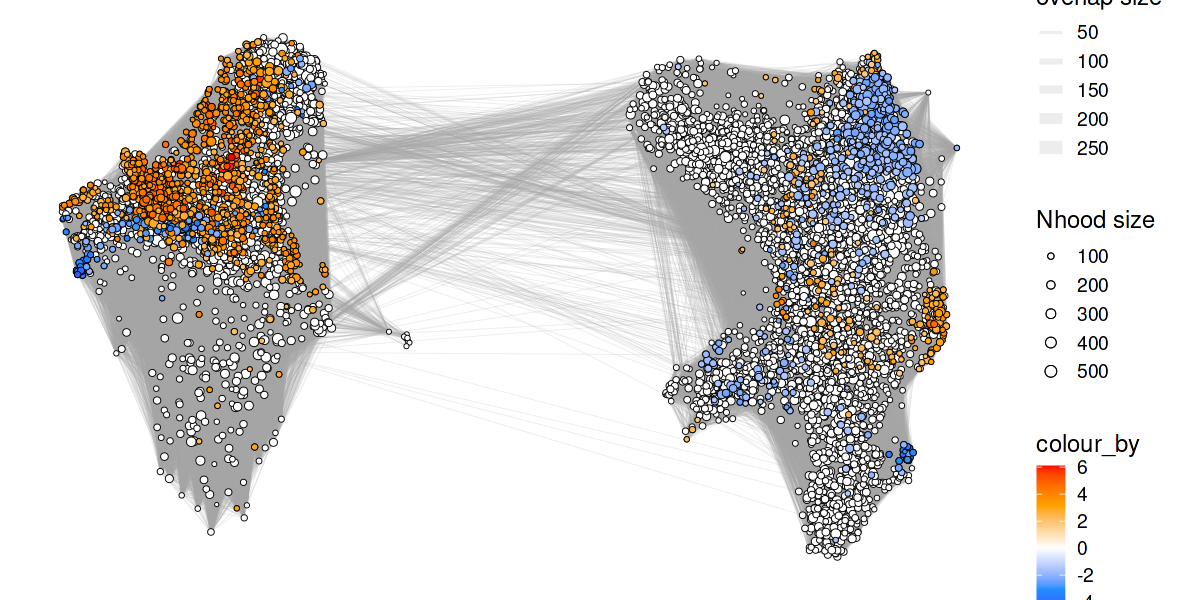

In [57]:
options(repr.plot.width=10, repr.plot.height=5)
plotNhoodGraphDA(milo, syno_state_da_results, alpha=0.1) +
  scale_fill_gradientn(
    colours = c("blue", "dodgerblue", "white", "orange", "red"),
    rescaler = ~ scales::rescale_mid(.x, mid = 0))

In [ ]:
syno_state_da_results <- annotateNhoods(milo, syno_state_da_results, coldata_col = "finalclusters")
head(da_results)

In [ ]:
syno_state_da_results$finalclusters <- syno_state_da_results$finalclusters <- as.ordered(factor(syno_state_da_results$finalclusters, levels=rev(c("LYVE1+ Macrophage","FOLR2+ Macrophage","TREM2+ Macrophage","ISG15+ Macrophage","SPP1+ Macrophage",
                                                          "IL1B+ Macrophage",
                                                         "CD14+S100A12+ Tissue Monocytes","CD16+ISG15+ Tissue Monocytes","CCR7+ DC","CD1c+ DC",
                                                         "Langerhans Cells (CD207+ DC)"))))

In [ ]:
options(repr.plot.width=5, repr.plot.height=4)
p <- plotDAbeeswarm(syno_state_da_results, group.by = "finalclusters") + theme_powerpoint() +
  scale_color_gradientn(
    colours = c("blue", "dodgerblue", "white", "orange", "red"),
    rescaler = ~ scales::rescale_mid(.x, mid = 0)) 


## Plot summary of disease state DA comparisons

In [ ]:
heart_state_da_results$tissue <- "Heart"
lung_state_da_results$tissue <- "Lung"
skin_state_da_results$tissue <- "Skin"
syno_state_da_results$tissue <- "Synovium"


In [ ]:
ncol(heart_state_da_results)

In [ ]:
state_da_results <- rbind(heart_state_da_results,lung_state_da_results,skin_state_da_results,syno_state_da_results)

In [ ]:
state_da_results$tissue_cluster <- paste0(state_da_results$tissue, "_", state_da_results$finalclusters)

In [ ]:
no.nhood <- as.data.frame(table(state_da_results$tissue_cluster))
head(no.nhood)

In [ ]:
sig_clusters <- no.nhood[which(no.nhood$Freq>5),"Var1"]

In [ ]:
# Optional: Subset for significant neighbourhoods
da_results_sig <- state_da_results %>% filter(SpatialFDR < 0.1)
da_results_sig <- da_results_sig[da_results_sig$tissue_cluster%in%sig_clusters,]
# Calculate average logFC by cell type
cluster_logFC <- da_results_sig %>%
  group_by(tissue_cluster) %>%
  summarise(MeanLogFC = mean(logFC)) 
library(ComplexHeatmap)

In [ ]:
cluster_logFC$tissue <- sub('_.*', '', cluster_logFC$tissue_cluster)
cluster_logFC$cluster <- sub('.*_', '', cluster_logFC$tissue_cluster)

In [ ]:
cluster_logFC$cluster <- as.ordered(factor(cluster_logFC$cluster, rev(levels(harmony.macro))))

In [ ]:
options(repr.plot.width=6, repr.plot.height=5)
ggplot(cluster_logFC, aes(tissue, cluster, fill= MeanLogFC)) + 
  geom_tile(color="black")+
  scale_fill_gradientn(
    colours = c("blue", "dodgerblue", "white", "orange", "red"),
    rescaler = ~ scales::rescale_mid(.x, mid = 0))  +  geom_text(aes(label = round(MeanLogFC,2)),size = 6, color = "white", fontface="bold") + theme_bw() 
